# Laboratorio di Simulazione Numerica - Esercizio 09

## Traveling Salesman Problem con algoritmo genetico

In questo esercizio si risolve numericamente il **Traveling Salesman Problem** (TSP) con un algoritmo genetico. Dato un insieme di $N$ città, lo scopo è trovare il cammino chiuso più breve che visita ogni città una sola volta e ritorna alla città di partenza.

Nel codice le città sono numerate a partire da $0$. Un cammino è quindi rappresentato come una permutazione

$$
[0, i_1, i_2, \dots, i_{N-1}],
$$

con la città $0$ fissata in prima posizione. Questa scelta non modifica il problema fisico, ma elimina una degenerazione banale: lo stesso ciclo può essere scritto partendo da una qualunque città. Rimane invece la degenerazione tra verso orario e antiorario dello stesso percorso.

## Funzione costo

La funzione costo usata nel codice è la lunghezza euclidea totale del cammino chiuso:

$$
L^{(1)} = \sum_{i=0}^{N-1} |\vec{x}_{p_i}-\vec{x}_{p_{i+1}}|,
\qquad p_N \equiv p_0.
$$

Questa è la quantità richiesta dalla consegna per il confronto finale. Nel codice viene calcolata dal metodo `Individual::ComputeLength`, sommando le distanze tra città consecutive e aggiungendo infine il collegamento dall'ultima città alla prima.

```cpp
void Individual::ComputeLength(const Map& map) {

    _length = 0.0;

    int n_cities = _path.size();

    for(int i = 0; i < n_cities - 1; i++) {
        _length += map.Distance(_path[i], _path[i + 1]);
    }

    _length += map.Distance(_path[n_cities - 1], _path[0]);
}
```

## Struttura dell'algoritmo genetico

La popolazione è composta da molti individui, dove ogni individuo è un possibile cammino. A ogni generazione il codice:

1. ordina la popolazione per lunghezza crescente;
2. seleziona due genitori con probabilità maggiore per gli individui migliori;
3. applica il crossover (spiegato in seguito) con probabilità $P_c$;
4. applica mutazioni casuali;
5. controlla che i figli siano ancora cammini validi;
6. ricalcola le lunghezze e costruisce la nuova generazione.

Il controllo di validità è una parte essenziale dell'esercizio: un individuo è accettabile solo se la città $0$ rimane in prima posizione e tutte le città compaiono esattamente una volta.

```cpp
bool Individual::Check() const {

    int n_cities = _path.size();

    if(n_cities == 0) return false;
    if(_path[0] != 0) return false;

    vector<int> counter(n_cities, 0);

    for(int i = 0; i < n_cities; i++) {
        if(_path[i] < 0 || _path[i] >= n_cities) return false;
        counter[_path[i]]++;
    }

    for(int i = 0; i < n_cities; i++) {
        if(counter[i] != 1) return false;
    }

    return true;
}
```

## Selezione, crossover e mutazioni

La selezione usa il rango dell'individuo nella popolazione ordinata:

$$
j = \mathrm{int}(M r^p),
$$

con $M$ dimensione della popolazione, $r \in [0,1)$ uniforme e $p=1.5$. Poiché $r^p$ è più spesso vicino a zero quando $p>1$, gli individui con indice piccolo, cioè quelli migliori, vengono selezionati più frequentemente.

Il crossover conserva una prima parte del primo genitore e completa il figlio inserendo le città mancanti nell'ordine in cui compaiono nell'altro genitore. In questo modo il vincolo di permutazione viene preservato.

Le mutazioni implementate sono quattro:

- ``swap``       : scambio di due città, esclusa la prima;
- ``inversion``  : inversione di un tratto del cammino;
- ``shift``      : traslazione di un blocco contiguo;
- ``block_swap`` : scambio di due blocchi contigui della stessa lunghezza.

Tutti gli operatori agiscono solo sulle posizioni successive alla prima, quindi la città $0$ resta fissata.

## Parametri della simulazione

I parametri usati per i risultati mostrati sotto sono:

| parametro | valore |
|---|---:|
| numero di città | $34$ |
| dimensione popolazione | $1000$ |
| generazioni cerchio| $200$ |
| generazioni quadrato | $10000$ |
| probabilità di crossover | $0.8$ |
| probabilità di swap mutation | $0.1$ |
| probabilità di inversion mutation | $0.1$ |
| probabilità di shift mutation | $0.1$ |
| probabilità di block-swap mutation | $0.1$ |
| esponente di selezione | $p=1.5$ |

Nel codice è stato implementato ma non è stato utilizzato elitismo, cioè il miglior individuo di una generazione non viene copiato automaticamente nella generazione successiva. Per questo motivo la curva del miglior cammino non è matematicamente obbligata a essere monotona, anche se in pratica tende comunque a diminuire durante l'evoluzione.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(".")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

def load_case(case):
    cities = np.loadtxt(ROOT / "INPUT" / f"cities_{case}.dat")
    progress = np.loadtxt(ROOT / "OUTPUT" / f"progress_{case}.dat")
    path = np.loadtxt(ROOT / "OUTPUT" / f"best_path_coordinates_{case}.dat")
    return cities, progress, path

def closed_path_length(path):
    steps = np.diff(path, axis=0)
    return np.sum(np.sqrt(np.sum(steps**2, axis=1)))

def plot_cities(cities, title):
    city_index = cities[:, 0].astype(int)
    x = cities[:, 1]
    y = cities[:, 2]

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, label="Cities")
    plt.scatter(x[0], y[0], s=90, label="Fixed city 0")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()

def plot_progress(progress, title, reference=None, reference_label=None):
    generation = progress[:, 0]
    best = progress[:, 1]
    mean_best_half = progress[:, 2]

    plt.figure(figsize=(9, 5))
    plt.plot(generation, best, label="Best path")
    plt.plot(generation, mean_best_half, label="Average over best half")

    # La reference ha senso nel caso del cerchio ma non nel caso del quadrato.
    if reference is not None:
        plt.axhline(reference, linestyle="--", label=reference_label)

    plt.xlabel("Generation")
    plt.ylabel(r"$L^{(1)}$")
    plt.title(title)
    plt.legend()
    plt.show()

    print(f"Final best length:   {best[-1]:.5f}")
    print(f"Final average over the best half: {mean_best_half[-1]:.5f}")

def plot_best_path(cities, path, title):
    length = closed_path_length(path)

    plt.figure(figsize=(7, 7))
    plt.plot(path[:, 0], path[:, 1], marker="o", linewidth=1.5, label="Best path")
    plt.scatter(cities[:, 1], cities[:, 2], s=35, label="Cities")
    plt.scatter(cities[0, 1], cities[0, 2], s=100, label="Fixed city 0")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()

    print(f"Best path length recomputed from coordinates: {length:.4f}")

# Città sulla circonferenza

Nel primo caso le $34$ città sono generate casualmente sulla circonferenza di raggio unitario. In questa geometria ci si aspetta che il cammino ottimale segua l'ordinamento angolare delle città, evitando attraversamenti interni. La lunghezza del cammino ottimale non è esattamente $2\pi$, perché il percorso è una poligonale formata da corde della circonferenza; per un numero finito di punti risulta quindi leggermente minore della lunghezza della circonferenza.

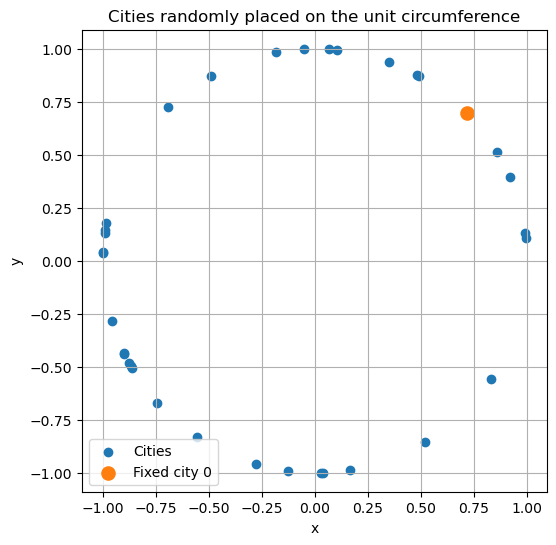

In [2]:
cities_circle, progress_circle, path_circle = load_case("circle")
plot_cities(cities_circle, "Cities randomly placed on the unit circumference")

## Evoluzione della lunghezza

Nel grafico seguente confronto il miglior valore di $L^{(1)}$ della popolazione con la media di $L^{(1)}$ sulla metà migliore della popolazione. La seconda quantità è utile perché misura non solo il singolo individuo migliore, ma anche quanto la parte buona della popolazione si sta concentrando verso cammini corti.

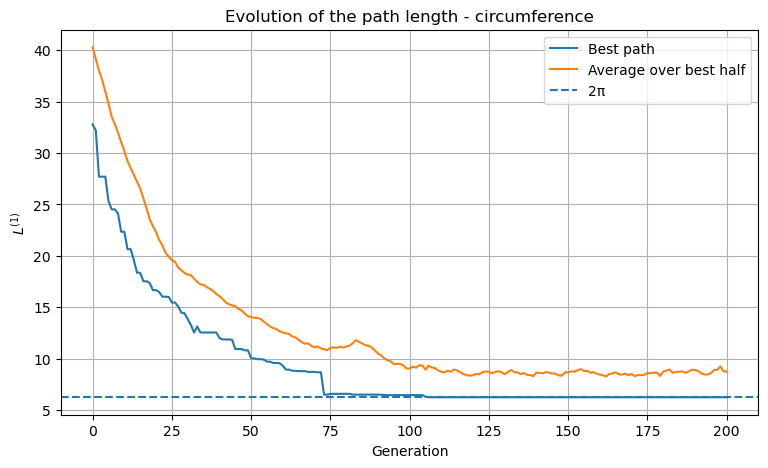

Final best length:   6.24306
Final average over the best half: 8.72370


In [3]:
plot_progress(
    progress_circle,
    "Evolution of the path length - circumference",
    reference=2*np.pi,
    reference_label="2π"
)

Il valore finale coincide, entro la precisione stampata, con il cammino ottenuto ordinando le città per angolo polare. Questo è un buon controllo del funzionamento dell'algoritmo: sulla circonferenza la soluzione migliore deve seguire il bordo senza creare incroci.

La media sulla metà migliore resta più alta del best path. Questo è normale: anche quando è stato trovato un cammino ottimo o quasi ottimo, non tutti gli individui migliori della popolazione sono identici.

## Miglior cammino trovato

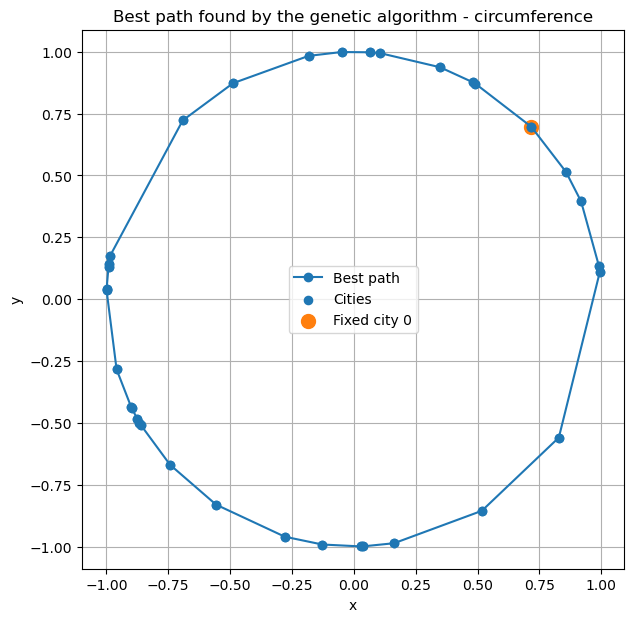

Best path length recomputed from coordinates: 6.2431


In [4]:
plot_best_path(
    cities_circle,
    path_circle,
    "Best path found by the genetic algorithm - circumference"
)

Il cammino segue la circonferenza senza attraversamenti.

# Città nel quadrato

Nel secondo caso le $34$ città sono generate casualmente all'interno del quadrato unitario. Questa configurazione è più difficile della precedente, perché non esiste un ordinamento geometrico semplice come l'angolo polare sulla circonferenza.

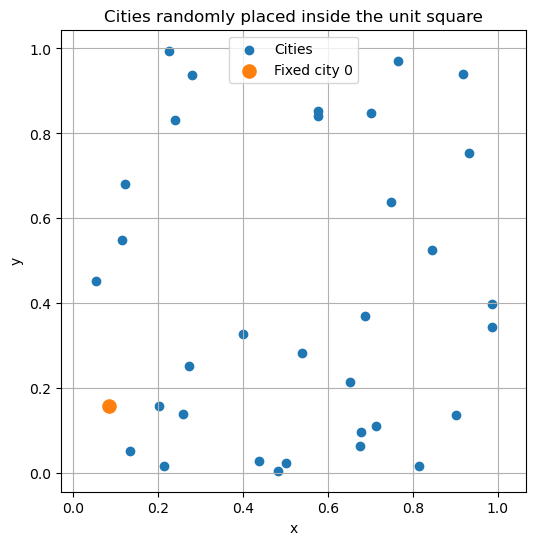

In [5]:
cities_square, progress_square, path_square = load_case("square")
plot_cities(cities_square, "Cities randomly placed inside the unit square")

## Evoluzione della lunghezza

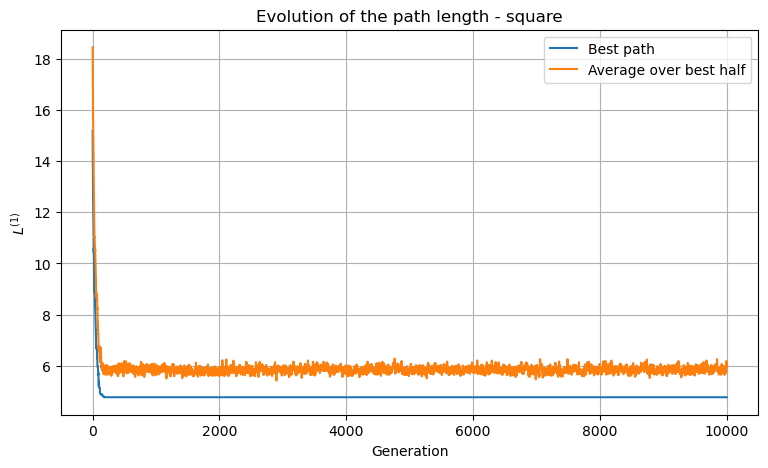

Final best length:   4.76839
Final average over the best half: 5.96138


In [6]:
plot_progress(
    progress_square,
    "Evolution of the path length - square"
)

Nel caso del quadrato la discesa iniziale è rapida: nelle prime generazioni la selezione elimina molti cammini molto lunghi, mentre crossover e mutazioni ricombinano sottostrutture favorevoli. Successivamente il miglioramento diventa più lento, perché l'algoritmo lavora su differenze sempre più piccole tra percorsi già abbastanza buoni.

Il fatto che la media sulla metà migliore rimanga sopra il miglior individuo indica che la popolazione conserva ancora una certa diversità. Questo è positivo fino a un certo punto: troppa diversità impedirebbe la convergenza, ma una popolazione troppo uniforme rischierebbe di bloccarsi prematuramente in un minimo locale.

## Miglior cammino trovato

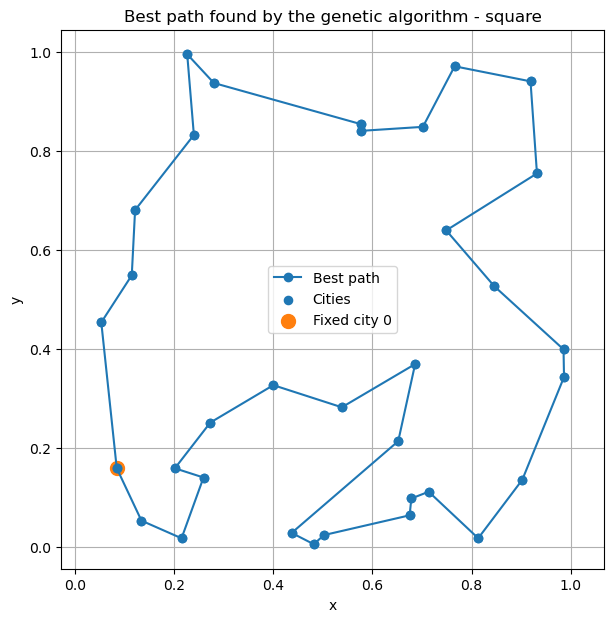

Best path length recomputed from coordinates: 4.7684


In [7]:
plot_best_path(
    cities_square,
    path_square,
    "Best path found by the genetic algorithm - square"
)

Il cammino finale non mostra grandi attraversamenti inutili e collega città vicine in gruppi locali, come ci si aspetta per una buona soluzione del TSP euclideo. A differenza del caso sulla circonferenza, qui non abbiamo un valore esatto semplice con cui confrontare il risultato; quindi il valore ottenuto va interpretato come il miglior cammino trovato dall'algoritmo genetico con i parametri scelti.

# Conclusioni

L'algoritmo genetico riesce a ridurre significativamente la lunghezza del cammino in entrambe le geometrie. Il caso sulla circonferenza fornisce un controllo particolarmente chiaro: il percorso finale coincide con quello ottenuto ordinando le città lungo il bordo, con lunghezza

$$
L^{(1)} \simeq 6.24306,
$$

leggermente minore di $2\pi$ perché il cammino è formato da corde.

Nel caso del quadrato il miglior cammino trovato ha lunghezza

$$
L^{(1)} \simeq 4.76839.
$$

La differenza principale tra i due casi è concettuale: sulla circonferenza la struttura della soluzione è quasi determinata dalla geometria, mentre nel quadrato l'algoritmo deve effettivamente esplorare e ricombinare molte configurazioni diverse. Per questo il secondo caso è un test più significativo della capacità dell'algoritmo genetico di ottimizzare il percorso.